# This script is for extraction and plotting capacity fade data from EMSI simulations

## Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
import matplotlib.ticker as tck
from pathlib import Path

# Global plotting defaults used by all figures in this notebook.
FONT = {"size": 12}
matplotlib.rc("font", **FONT)
plt.rcParams["axes.labelsize"] = 14


## Enter the folder path here

In [5]:
# Directory containing the exported simulation CSV files for this study.
folder = Path("../raw_data")


## Functions for data extraction and plotting

In [7]:
def plot_capacity_fade(filename, label=None, ylim=None, linewidth=2, marker=".", c=None, skipfooter=0):
    """Read a capacity-fade CSV file and plot normalized discharge capacity."""
    df = pd.read_csv(
        filename,
        skiprows=8,
        names=["cycle_nr", "t_dch"],
        skipfooter=skipfooter,
        engine="python",
    )

    # Some files contain repeated entries per cycle, so average before plotting.
    df = df.groupby("cycle_nr", as_index=False).mean()

    # Normalize discharge capacity to the first cycle.
    discharge_capacity = 100 * df["t_dch"] / df.iloc[0]["t_dch"]

    plt.scatter(df["cycle_nr"], discharge_capacity, label=label, marker=marker, linewidth=linewidth)
    plt.plot(df["cycle_nr"][:-1], discharge_capacity[:-1], "-", alpha=0.2)
    plt.legend()
    plt.ylabel("Capacity [%]")
    plt.xlabel("Cycle number")
    plt.grid(alpha=0.5)


def set_axis_options(ax, title, ncols=2):
    """Apply the shared axis formatting used across the capacity-fade figures."""
    ax.grid(alpha=0.5)
    ax.grid(which="minor", alpha=0.5)
    ax.xaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
    ax.yaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
    ax.set_xticks(np.arange(0, 40.1, 10))
    ax.set_xlim(0, 40.6)
    ax.legend(
        framealpha=1,
        markerscale=1,
        handletextpad=0.25,
        handlelength=1,
        ncols=ncols,
        columnspacing=0.8,
        title=title,
        fontsize=11,
        title_fontsize=11,
        borderaxespad=0.2,
        loc="lower left",
    )


## Plot capacity fade for different C-rates
##### The capacity vs cycle number shows a clear capacity fade over 40 cycles at C-rates above 0.5C, with higher C-rates resulting in larger capacity fade

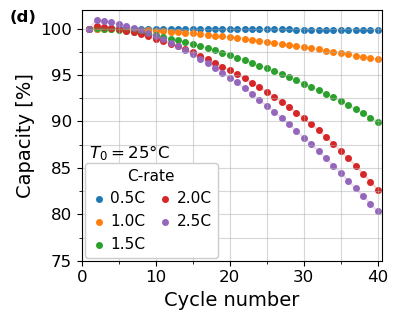

In [56]:
fig, ax = plt.subplots(1, 1, figsize=(4.2, 3.36))

# Compare capacity fade at different C-rates.
simulation_list = ["C_rate_0.5", "C_rate_1", "C_rate_1.5", "C_rate_2", "C_rate_2.5"]
label_list = ["0.5C", "1.0C", "1.5C", "2.0C", "2.5C"]
filename_list = [
    folder / f"capacity_fade_{sim}_T_ref_298_Permeability_1.9E-15_r_pos_7.csv"
    for sim in simulation_list
]

for filename, label in zip(filename_list, label_list):
    plot_capacity_fade(filename, label=label)

ax.set_ylim(75, 102)
set_axis_options(ax, title="C-rate")
numbering = (-9.7, "(d)")
ax.text(numbering[0], ax.get_ylim()[1], numbering[1], weight="bold", verticalalignment="top")
ax.text(1, 86, r"$T_\text{0}=25\degree$C", c="black")

plt.tight_layout()
plt.savefig("../plots/capcity_fade_vs_C_rate.png", format="png", dpi=500)


## Plot capacity fade for different temperatures
##### Lower temperatures result in higher capacity fade due to worsened electrolyte transport properties and slower diffusion re-homogenization

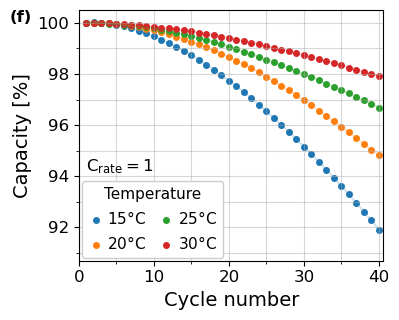

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(4.2, 3.36))

# Compare capacity fade at different reference temperatures.
# Only the temperature cases below are included in this figure.
simulation_list = np.array(["T_ref_288", "T_ref_293", "T_ref_298", "T_ref_303"])
label_list = np.array([r"$15 \degree$C", r"$20 \degree$C", r"$25 \degree$C", r"$30 \degree$C"])
filename_list = [
    folder / f"capacity_fade_C_rate_1_{sim}_Permeability_1.9E-15_r_pos_7.csv"
    for sim in simulation_list
]

for filename, label in zip(filename_list, label_list):
    plot_capacity_fade(filename, label=label)

plt.ylim(90.7, 100.5)
set_axis_options(ax, title="Temperature")
numbering = (-9.2, "(f)")
ax.text(numbering[0], ax.get_ylim()[1], numbering[1], weight="bold", verticalalignment="top")
ax.text(1, 94.2, r"C$_\text{rate}$$=1$", c="black")

plt.tight_layout()
plt.savefig("../plots/capcity_fade_vs_temperature.png", format="png", dpi=500)


## Plot capacity fade for different permeabilities
##### Equal anode-and-cathode permeability (3.0E-15m^2) results in no capacity fade. Both higher and lower anode permeability leads to capacity fade due to EMSI, though high anode permeability is more detrimental

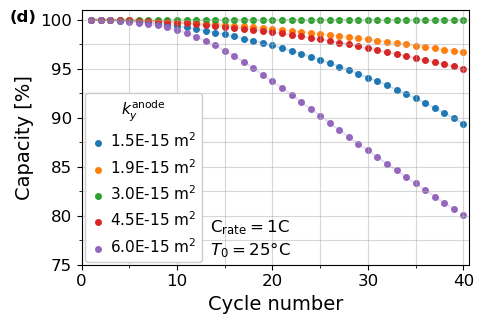

In [91]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3.4))

# Compare capacity fade at different anode permeabilities.
simulation_list = [
    "Permeability_1.5E-15",
    "Permeability_1.9E-15",
    "Permeability_3E-15",
    "Permeability_4.5E-15",
    "Permeability_6E-15",
]
label_list = [
    r"1.5E-15 $\text{m}^2$",
    r"1.9E-15 $\text{m}^2$",
    r"3.0E-15 $\text{m}^2$",
    r"4.5E-15 $\text{m}^2$",
    r"6.0E-15 $\text{m}^2$",
]
filename_list = [
    folder / f"capacity_fade_C_rate_1_T_ref_298_{sim}_r_pos_7.csv"
    for sim in simulation_list
]

for filename, label in zip(filename_list, label_list):
    plot_capacity_fade(filename, label=label)

plt.ylim(75, 101)
set_axis_options(ax, title=r"$k_y^\text{anode}$", ncols=1)
numbering = (-7.5, "(d)")
if numbering is not None:
    ax.text(numbering[0], ax.get_ylim()[1], numbering[1], weight="bold", verticalalignment="top")
ax.text(13.5, 76, r"C$_\text{rate}$$=1$C" "\n" r"$T_\text{0}=25\degree$C", c="black")

plt.tight_layout()
plt.savefig("../plots/capcity_fade_vs_permeability.png", format="png", dpi=500)


## Plot 1C capacity fade with rest-after-40-cycles datapoint
##### The capacity vs cycle number shows a clear capacity fade over 40 cycles at 1C, but a 3-day rest period before cycle 41 allow the capacity to recover significantly

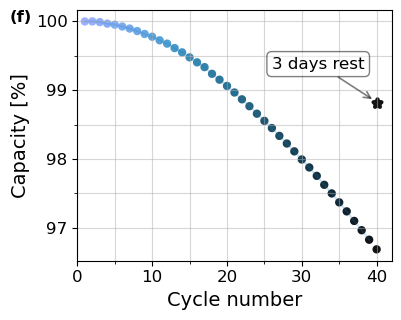

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(4.2, 3.36))

# Load the reference 1C simulation and normalize capacity to the first cycle.
filename = folder / "capacity_fade_C_rate_1_T_ref_298_Permeability_1.9E-15_r_pos_7.csv"
df = pd.read_csv(
    filename,
    skiprows=8,
    names=["cycle_nr", "t_dch"],
    skipfooter=1,
    engine="python",
)
df = df.groupby("cycle_nr", as_index=False).mean()
discharge_capacity = 100 * df["t_dch"] / df.iloc[0]["t_dch"]

n_cycles = len(discharge_capacity)
cmap = plt.get_cmap("berlin", int(n_cycles * 2.1))
colors = np.array([cmap(i) for i in range(cmap.N)])

plt.scatter(df["cycle_nr"], discharge_capacity, marker=".", linewidth=3, c=colors[:n_cycles])
plt.plot(df["cycle_nr"][:-1], discharge_capacity[:-1], "-", alpha=0.2)
plt.ylabel("Capacity [%]")
plt.xlabel("Cycle number")
plt.grid(alpha=0.5)

ax.grid(which="minor", alpha=0.5)
ax.xaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
ax.yaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
ax.set_xlim(0, len(discharge_capacity) + 2)
ax.set_xticks(np.arange(0, 40.1, 10))

# Capacity after a 3-day rest period, taken from a separate COMSOL simulation.
discharge_capacity_after_rest = 98.82
ax.scatter(
    n_cycles,
    discharge_capacity_after_rest,
    marker="*",
    linewidth=3,
    color=colors[n_cycles - 1],
    alpha=1,
)

# Annotate the rest-period point.
xy = (39.4, 98.87)
xytext = (26, 99.38)

plt.annotate(
    "3 days rest",
    xy=xy,
    xytext=xytext,
    textcoords="data",
    arrowprops=dict(
        arrowstyle="->",
        lw=1.2,
        color="black",
        shrinkA=0,
        shrinkB=0,
        alpha=0.5,
    ),
    bbox=dict(
        boxstyle="round,pad=0.3",
        fc="white",
        ec="black",
        alpha=0.5,
    ),
    ha="left",
    va="center",
)

numbering = (-9, "(f)")
if numbering is not None:
    ax.text(numbering[0], ax.get_ylim()[1], numbering[1], weight="bold", verticalalignment="top")

plt.tight_layout()
plt.savefig("../plots/capcity_fade_1C_with_rest.png", format="png", dpi=500)
